## Sparse Autoencoder for Online Shopping Behaviour

---

## Project Overview

This notebook uses a **Sparse Autoencoder** on online shopping session data.

Each row in the dataset represents one website visit/session.

The goal is not to predict purchase directly.  
The goal is to learn a smaller and cleaner representation of customer behaviour.

A sparse autoencoder tries to answer this question:

> Can we understand customer behaviour using fewer important hidden signals?

---

## Business Context

In digital marketing, every website session tells a story.

A visitor may:

- visit many product pages,
- spend time reading information,
- leave quickly,
- return as an existing customer,
- visit during the weekend,
- or show strong purchase interest.

Instead of looking at many raw columns separately, an autoencoder can compress the session into a smaller set of useful behaviour features.

This can help with customer behaviour analysis, segmentation, and future anomaly detection.

---

## Business Questions

| Business Question | Simple Meaning |
|---|---|
| Can we compress website session behaviour into fewer useful features? | Can we reduce many columns into a smaller behaviour summary? |
| Do purchase and non-purchase sessions look different in hidden space? | Do buyers and non-buyers behave differently? |
| Can sparsity remove unnecessary noise from behaviour data? | Can the model focus only on the most useful signals? |
| Does the sparse autoencoder use fewer active neurons? | Is the model really becoming sparse? |
| Does sparsity reduce reconstruction quality? | Do we lose information when we force the model to be simpler? |
| Can the compressed features help later with segmentation or anomaly detection? | Can these learned features be useful for future business analysis? |

---

## Theory Connection

A normal autoencoder learns this:

`input features → bottleneck → reconstructed input features`

A **Sparse Autoencoder** does the same thing, but adds one extra rule:

> Do not use all bottleneck neurons all the time.

This means the model is encouraged to use only the most important hidden neurons.

| Model | Simple Idea |
|---|---|
| Normal Autoencoder | Can use many bottleneck neurons freely |
| Sparse Autoencoder | Tries to use fewer active bottleneck neurons |

---

## Dataset Context

The dataset contains website-session features such as:

| Feature Group | Examples |
|---|---|
| Page activity | Number of pages visited |
| Time behaviour | Time spent on different page types |
| Website engagement | Bounce rate and exit rate |
| Purchase interest | Page value |
| Visit context | Month, visitor type, weekend |
| Outcome | Revenue / purchase or no purchase |

The purchase outcome will be used only for interpretation.  
The autoencoder itself learns by reconstructing session features.

---

## Practical Goal

We will build and compare:

1. **Normal Autoencoder**  
   Learns to reconstruct shopping session data normally.

2. **Sparse Autoencoder**  
   Learns to reconstruct shopping session data while trying to use fewer active bottleneck neurons.

We will compare:

| Area | What We Check |
|---|---|
| Reconstruction error | Which model rebuilds the session data better? |
| Bottleneck activity | Which model uses fewer active hidden neurons? |
| Sparse behaviour | Did L1 regularization actually make the bottleneck sparse? |
| Hidden patterns | Do the compressed features show useful customer behaviour structure? |
| Business meaning | How can this help marketing or customer analysis? |

---

## Main Learning Objective

By the end of this notebook, we should understand:

> How sparse autoencoders can learn compact behaviour features from website sessions, and what trade-off happens between reconstruction quality and simpler hidden representations.

## 1. Environment Setup

This section imports the libraries needed for the sparse autoencoder project.

We use these libraries for four main tasks:

| Task | Libraries |
|---|---|
| Data handling | NumPy, Pandas |
| Charts | Matplotlib |
| Autoencoder modelling | TensorFlow, Keras |
| Preprocessing and splitting | Scikit-learn |

The notebook will follow a clean workflow:

`load data → inspect data → preprocess data → split data → train models → compare results → interpret business meaning`

In [1]:
# ============================================================
# Sparse Autoencoder on Online Shoppers Behaviour Data
# Environment Setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error

# Reproducibility: helps us get similar results each time we run the notebook
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

# Check whether TensorFlow can use GPU
gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpus) > 0)

if gpus:
    print("GPU device:", gpus[0].name)
else:
    print("Running on CPU")

2026-06-07 00:58:45.438267: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2
NumPy version: 1.26.4
GPU available: False
Running on CPU


## 1. Load the Online Shoppers Dataset

We now load the Online Shoppers Purchasing Intention dataset.

This dataset is relevant for digital marketing analytics because it contains website-session behaviour features.

In this sparse autoencoder notebook, the goal is not classification.  
Instead, we use the dataset to learn a compact representation of session behaviour.

## 2. Load the Online Shoppers Dataset

We now load the **Online Shoppers Purchasing Intention** dataset.

Each row represents one website session.

The dataset is useful for this sparse autoencoder because each session contains behaviour signals such as page visits, time spent, bounce rate, exit rate, page value, visitor type, weekend activity, and purchase outcome.

In this notebook, the autoencoder will learn:

`session behaviour features → compressed bottleneck → reconstructed session behaviour features`

The purchase column will be used later only for interpretation, not as the direct training target.

In [2]:
# ============================================================
# Load Online Shoppers Dataset
# ============================================================

data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"

# Source: online shoppers session dataset
# Logic: each row is one website visit/session
data = pd.read_csv(data_url)

print("Dataset loaded successfully.")
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

display(data.head())

Dataset loaded successfully.
Rows: 12330
Columns: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### Dataset Loading — Conclusion

The Online Shoppers dataset was loaded successfully.

The dataset contains **12,330 website sessions** and **18 columns**.

Each row represents one user session on an e-commerce website.

Each column describes something about that session, such as page visits, 
time spent, traffic behaviour, visitor type, weekend visit, or purchase outcome.

Next, we inspect the columns, data types, missing values, and purchase distribution.

## 3. Dataset Overview

Before building the sparse autoencoder, we need to understand the dataset structure.

In this section, we check:

| Check | Why it matters |
|---|---|
| Column names | Understand what features are available |
| Data types | Identify numeric and categorical columns |
| Missing values | Check whether cleaning is needed |
| Purchase outcome | Understand the business target for interpretation |

The autoencoder will not directly predict purchase.  
However, the purchase column helps us later interpret whether hidden behaviour patterns differ between purchase and non-purchase sessions.

In [3]:
# ============================================================
# Inspect Dataset Structure
# ============================================================

# Basic column overview
print("Column names:")
print(data.columns.tolist())

print("\nData types:")
display(data.dtypes.to_frame(name="Data Type"))

# Missing value check
missing_values = data.isnull().sum().to_frame(name="Missing Values")
missing_values["Missing %"] = (missing_values["Missing Values"] / len(data) * 100).round(2)

print("\nMissing value summary:")
display(missing_values)

# Purchase outcome distribution
purchase_counts = data["Revenue"].value_counts().rename_axis("Revenue").reset_index(name="Sessions")
purchase_counts["Share %"] = (purchase_counts["Sessions"] / purchase_counts["Sessions"].sum() * 100).round(2)

print("\nPurchase outcome distribution:")
display(purchase_counts)

Column names:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Data types:


,Data Type
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64



Missing value summary:


,Missing Values,Missing %
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0



Purchase outcome distribution:


,Revenue,Sessions,Share %
0,False,10422,84.53
1,True,1908,15.47


### Dataset Overview — Conclusion

The dataset contains a mix of numeric, categorical, and boolean columns.

The main purchase outcome column is **Revenue**.

The purchase distribution shows that most sessions did not end in purchase:

| Revenue | Meaning | Share |
|---|---|---|
| False | No purchase | 84.53% |
| True | Purchase | 15.47% |

This tells us that purchase sessions are the minority.

For this notebook, we will not train the autoencoder to predict Revenue directly.  
Instead, Revenue will be kept separately and used later for interpretation.

The autoencoder will learn hidden behaviour patterns from the session features.

## 5. Chart Styling Setup

To keep the notebook visually consistent, we define a small chart styling setup.

This helps all charts look clean, readable, and business-ready.

The goal is not just to create charts, but to make each chart tell a clear data story.

In [4]:
# ============================================================
# Chart Styling Setup
# ============================================================

# Professional chart color palette
COLOR_PRIMARY = "#1F4E79"
COLOR_SECONDARY = "#70AD47"
COLOR_ACCENT = "#C00000"
COLOR_GREY = "#6E6E6E"
COLOR_LIGHT_GREY = "#D9E2F3"

def format_chart(ax, title, subtitle=None, xlabel=None, ylabel=None):
    """
    Apply consistent BI-style formatting to matplotlib charts.

    Source:
        ax = chart axis created by matplotlib

    Logic:
        Keep charts clean, readable, and presentation-ready.
    """
    ax.set_title(title, fontsize=17, fontweight="bold", pad=22)

    if subtitle:
        ax.text(
            0,
            1.04,
            subtitle,
            transform=ax.transAxes,
            fontsize=11,
            color=COLOR_GREY
        )

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=12)

    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.tick_params(axis="both", labelsize=11)

print("Chart styling setup completed.")

Chart styling setup completed.


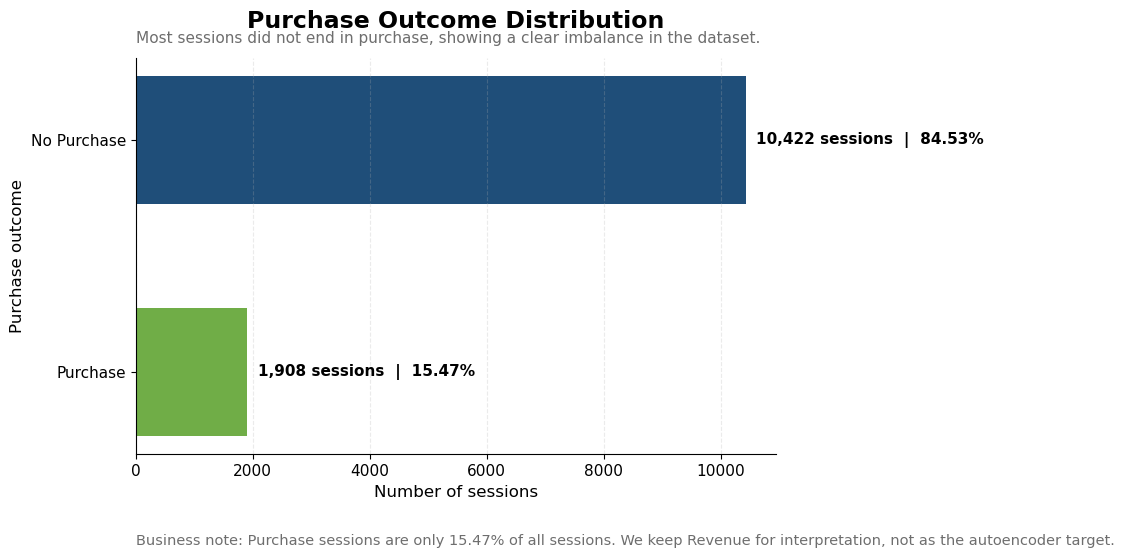

In [5]:
# ============================================================
# Purchase Outcome Distribution Chart
# ============================================================

purchase_chart = purchase_counts.copy()

purchase_chart["Outcome"] = purchase_chart["Revenue"].map({
    False: "No Purchase",
    True: "Purchase"
})

purchase_chart = purchase_chart.sort_values("Sessions", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5.8))

bar_colors = [COLOR_PRIMARY if outcome == "No Purchase" else COLOR_SECONDARY
              for outcome in purchase_chart["Outcome"]]

bars = ax.barh(
    purchase_chart["Outcome"],
    purchase_chart["Sessions"],
    color=bar_colors,
    height=0.55
)

for bar, sessions, share in zip(
    bars,
    purchase_chart["Sessions"],
    purchase_chart["Share %"]
):
    ax.text(
        bar.get_width() + 180,
        bar.get_y() + bar.get_height() / 2,
        f"{sessions:,} sessions  |  {share:.2f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

format_chart(
    ax=ax,
    title="Purchase Outcome Distribution",
    subtitle="Most sessions did not end in purchase, showing a clear imbalance in the dataset.",
    xlabel="Number of sessions",
    ylabel="Purchase outcome"
)

ax.text(
    0,
    -0.23,
    "Business note: Purchase sessions are only 15.47% of all sessions. We keep Revenue for interpretation, not as the autoencoder target.",
    transform=ax.transAxes,
    fontsize=10.5,
    color=COLOR_GREY
)

plt.tight_layout()
plt.show()

### Purchase Distribution — Conclusion

The dataset is clearly imbalanced.

Most sessions did not end in purchase:

- **No Purchase:** 84.53%
- **Purchase:** 15.47%

This is normal for e-commerce data because only a smaller share of website visits usually convert into purchases.

For this notebook, this imbalance is not a training problem because the sparse autoencoder is not trained as a classifier.

However, the **Revenue** column is still useful for business interpretation. Later, we can check whether purchase and non-purchase sessions behave differently in the compressed bottleneck space.

## 5. Identify Feature Groups

Before preprocessing, we separate the columns into clear groups.

The sparse autoencoder will use session behaviour features as input.

The **Revenue** column will not be used as the reconstruction target.  
It will be kept separately only for business interpretation later.

### Why this step matters

Different column types need different preprocessing:

| Column type | Example | Preprocessing needed |
|---|---|---|
| Numeric columns | BounceRates, ExitRates, PageValues | Scaling |
| Categorical columns | Month, VisitorType | One-hot encoding |
| Boolean columns | Weekend | Convert to numeric |
| Interpretation column | Revenue | Keep separately |

In [6]:
# ============================================================
# Identify Feature Groups
# ============================================================

# Revenue is not used as the autoencoder target.
# It is kept separately for interpretation later.

target_column = "Revenue"

# Simple column groups

numeric_columns = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = data.select_dtypes(include=["object", "string"]).columns.tolist()
boolean_columns = data.select_dtypes(include=["bool"]).columns.tolist()

# Weekend is a feature, but Revenue is only for interpretation.

boolean_feature_columns = [col for col in boolean_columns if col != target_column]

# Final feature columns used by the autoencoder
feature_columns = numeric_columns + categorical_columns + boolean_feature_columns

print("Numeric columns:", len(numeric_columns))
print(numeric_columns)

print("\nCategorical columns:", len(categorical_columns))
print(categorical_columns)

print("\nBoolean feature columns:", len(boolean_feature_columns))
print(boolean_feature_columns)

print("\nInterpretation column:")
print(target_column)

print("\nTotal feature columns used for autoencoder:", len(feature_columns))

Numeric columns: 14
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorical columns: 2
['Month', 'VisitorType']

Boolean feature columns: 1
['Weekend']

Interpretation column:
Revenue

Total feature columns used for autoencoder: 17


### Feature Groups — Conclusion

The dataset columns were separated into clear groups.

We found:

| Feature group | Count | Meaning |
|---|---:|---|
| Numeric columns | 14 | Behaviour values such as page visits, time spent, bounce rate, exit rate, and page value |
| Categorical columns | 2 | Month and visitor type |
| Boolean feature columns | 1 | Weekend visit indicator |
| Interpretation column | 1 | Revenue |

The autoencoder will use **17 feature columns**.

The **Revenue** column is kept separately because it is not the reconstruction target.  
It will be used later to interpret whether purchase and non-purchase sessions show different hidden behaviour patterns.

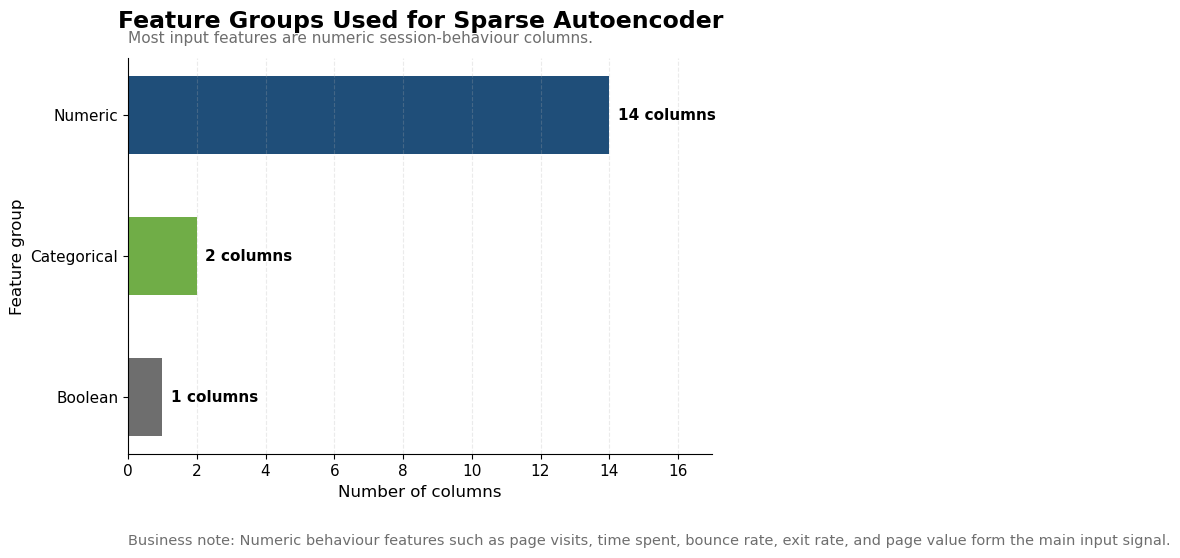

In [7]:
# ============================================================
# Feature Group Summary Chart
# ============================================================

feature_group_chart = pd.DataFrame({
    "Feature Group": ["Numeric", "Categorical", "Boolean"],
    "Column Count": [
        len(numeric_columns),
        len(categorical_columns),
        len(boolean_feature_columns)
    ]
})

feature_group_chart = feature_group_chart.sort_values("Column Count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5.8))

bars = ax.barh(
    feature_group_chart["Feature Group"],
    feature_group_chart["Column Count"],
    color=[COLOR_GREY, COLOR_SECONDARY, COLOR_PRIMARY],
    height=0.55
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.25,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)} columns",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

format_chart(
    ax=ax,
    title="Feature Groups Used for Sparse Autoencoder",
    subtitle="Most input features are numeric session-behaviour columns.",
    xlabel="Number of columns",
    ylabel="Feature group"
)

ax.set_xlim(0, feature_group_chart["Column Count"].max() + 3)

ax.text(
    0,
    -0.23,
    "Business note: Numeric behaviour features such as page visits, time spent, bounce rate, exit rate, and page value form the main input signal.",
    transform=ax.transAxes,
    fontsize=10.5,
    color=COLOR_GREY
)

plt.tight_layout()
plt.show()

### Feature Group Chart — Conclusion

Most features used by the autoencoder are numeric behaviour columns.

This is useful because numeric session features contain important information about how visitors interact with the website.

The categorical columns, such as **Month** and **VisitorType**, will be converted into numeric format using one-hot encoding.

The next step is preprocessing, where we prepare all features so they can be used by the neural network.

## 6. Create Train, Validation, and Test Sets

Before preprocessing, we split the dataset into three parts.

| Dataset part | Purpose |
|---|---|
| **Training set** | The model learns from this data |
| **Validation set** | Used to check performance during training |
| **Test set** | Used only at the end for final evaluation |

This is important because the model should not learn from the test data.

The **Revenue** column is kept separately.  
It is not used as the autoencoder target, but we keep it for later business interpretation.

In [8]:
# ============================================================
# Create Train, Validation, and Test Sets
# ============================================================

features = data[feature_columns].copy()
revenue = data[target_column].copy()

# First split:
# 70% goes to training
# 30% is kept aside for validation + test
train_features, remaining_features, train_revenue, remaining_revenue = train_test_split(
    features,
    revenue,
    test_size=0.30,
    random_state=42,
    stratify=revenue
)

# Second split:
# remaining 30% is split equally into validation and test
val_features, test_features, val_revenue, test_revenue = train_test_split(
    remaining_features,
    remaining_revenue,
    test_size=0.50,
    random_state=42,
    stratify=remaining_revenue
)

print("Training features:", train_features.shape)
print("Validation features:", val_features.shape)
print("Test features:", test_features.shape)

print("\nTraining revenue distribution:")
print(train_revenue.value_counts(normalize=True).round(4))

print("\nValidation revenue distribution:")
print(val_revenue.value_counts(normalize=True).round(4))

print("\nTest revenue distribution:")
print(test_revenue.value_counts(normalize=True).round(4))

Training features: (8631, 17)
Validation features: (1849, 17)
Test features: (1850, 17)

Training revenue distribution:
Revenue
False    0.8452
True     0.1548
Name: proportion, dtype: float64

Validation revenue distribution:
Revenue
False    0.8453
True     0.1547
Name: proportion, dtype: float64

Test revenue distribution:
Revenue
False    0.8454
True     0.1546
Name: proportion, dtype: float64


### Train / Validation / Test Split — Conclusion

The data was split properly into training, validation, and test sets.

| Dataset | Rows | Purpose |
|---|---:|---|
| Training | 8,631 | Used by the model to learn |
| Validation | 1,849 | Used to check performance during training |
| Test | 1,850 | Used only for final evaluation |

The purchase distribution stayed almost the same in all three sets.

This is important because the dataset is imbalanced. Keeping the same purchase ratio across train, validation, and test makes the comparison fair.

The next step is preprocessing. We will scale numeric columns and encode categorical columns so the neural network can use them.

## 7. Preprocess Features

Before training the autoencoder, we need to convert all input features into a numeric format that a neural network can understand.

The dataset contains different column types:

| Feature type | Example | What we do |
|---|---|---|
| Numeric columns | BounceRates, ExitRates, PageValues | Scale using `StandardScaler` |
| Categorical columns | Month, VisitorType | Convert using `OneHotEncoder` |
| Boolean columns | Weekend | Treat as numeric 0/1 values |

---

### Important Tool: `ColumnTransformer`

We use `ColumnTransformer` from Scikit-learn.

`ColumnTransformer` lets us apply different preprocessing steps to different column groups in one clean object.

In this notebook:

| Column group | Transformer used | Purpose |
|---|---|---|
| Numeric + Boolean features | `StandardScaler` | Brings values to a similar scale |
| Categorical features | `OneHotEncoder` | Converts text categories into numeric columns |

---

### Why this matters

Neural networks work better when input values are clean, numeric, and scaled.

For example:

- `ProductRelated_Duration` can have large values.
- `BounceRates` is usually between 0 and 1.
- `Month` is text and must be converted to numbers.
- `VisitorType` is also text and must be encoded.

Without preprocessing, the model would not learn properly.

---

### Avoiding Data Leakage

The preprocessor is fitted only on the training data:

`preprocessor.fit_transform(train_features)`

Then the same fitted preprocessor is applied to validation and test data:

`preprocessor.transform(val_features)`  
`preprocessor.transform(test_features)`

This is important because validation and test data should not influence how preprocessing is learned.

In [9]:
# ============================================================
# Preprocess Features
# ============================================================

numeric_features = numeric_columns + boolean_feature_columns
categorical_features = categorical_columns

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

# Fit only on training data

X_train = preprocessor.fit_transform(train_features)

# Apply same transformation to validation and test data

X_val = preprocessor.transform(val_features)
X_test = preprocessor.transform(test_features)

# TensorFlow works best with float32

X_train = X_train.astype("float32")
X_val = X_val.astype("float32")
X_test = X_test.astype("float32")

print("Processed training shape:", X_train.shape)
print("Processed validation shape:", X_val.shape)
print("Processed test shape:", X_test.shape)
print("\nInput features after preprocessing:", X_train.shape[1])

Processed training shape: (8631, 28)
Processed validation shape: (1849, 28)
Processed test shape: (1850, 28)

Input features after preprocessing: 28


### Preprocessing — Conclusion

The features were successfully prepared for the neural network.

The preprocessing step did three important things:

- numeric behaviour columns were scaled,
- text columns were converted into numeric columns,
- and the same transformation was applied to training, validation, and test data.

The number of input columns increased because categorical columns such as **Month** and **VisitorType** were converted into multiple one-hot encoded columns.

Next, we create a normal autoencoder baseline. This model will help us compare whether the sparse autoencoder improves bottleneck compactness later.

In [10]:
# ============================================================
# Check Processed Feature Space
# ============================================================

# Get final column names after scaling and one-hot encoding
processed_feature_names = preprocessor.get_feature_names_out()

input_dim = X_train.shape[1]       # number of final input features after preprocessing

bottleneck_dim = 12                # compressed hidden representation size

print("Final input dimension:", input_dim)
print("Bottleneck dimension:", bottleneck_dim)
print("\nFirst 10 processed feature names:")
print(processed_feature_names[:10])

Final input dimension: 28
Bottleneck dimension: 12

First 10 processed feature names:
['numeric__Administrative' 'numeric__Administrative_Duration'
 'numeric__Informational' 'numeric__Informational_Duration'
 'numeric__ProductRelated' 'numeric__ProductRelated_Duration'
 'numeric__BounceRates' 'numeric__ExitRates' 'numeric__PageValues'
 'numeric__SpecialDay']


## 8. Build the Normal Autoencoder Baseline

We first build a normal autoencoder.

This model has no sparsity rule.
  
It is free to use the bottleneck neurons however it wants.

The model learns:

`session features → bottleneck → reconstructed session features`

### Why we need a baseline

The normal autoencoder gives us a comparison point.

Later, we will build a sparse autoencoder and compare:

| Question | Why it matters |
|---|---|
| Which model reconstructs better? | Measures information loss |
| Which model uses fewer active bottleneck neurons? | Measures sparsity |
| What is the trade-off? | Helps understand sparse representation learning |

In [11]:
# ============================================================
# Build Normal Autoencoder Baseline
# ============================================================

# Input layer:
# Each row is one preprocessed shopping session.
input_layer = keras.Input(shape=(input_dim,), name="session_input")

# Encoder:
# Compress session features into a smaller hidden representation.
x = layers.Dense(32, activation="relu", name="encoder_dense_32")(input_layer)

# Bottleneck:
# This is the compressed behaviour representation.
bottleneck = layers.Dense(bottleneck_dim, activation="relu", name="normal_bottleneck")(x)

# Decoder:
# Rebuild the original session feature vector from the bottleneck.
x = layers.Dense(32, activation="relu", name="decoder_dense_32")(bottleneck)

# Output layer:
# Linear output is used because scaled numeric values can be negative.
output_layer = layers.Dense(input_dim, activation="linear", name="reconstructed_session")(x)

# Full autoencoder model
normal_autoencoder = keras.Model(
    inputs=input_layer,
    outputs=output_layer,
    name="normal_autoencoder"
)

# Separate encoder model for later bottleneck analysis
normal_encoder = keras.Model(
    inputs=input_layer,
    outputs=bottleneck,
    name="normal_encoder"
)

normal_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

normal_autoencoder.summary()

Model: "normal_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ session_input (InputLayer)      │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_32 (Dense)        │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normal_bottleneck (Dense)       │ (None, 12)             │           396 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_32 (Dense)        │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_session (Dense)   │ (None, 28)             │           924 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,664 (10.41 KB)

 Trainable params: 2,664 (10.41 KB)

 Non-trainable params: 0 (0.00 B)

### Normal Autoencoder Architecture — Conclusion

The normal autoencoder baseline was created successfully.

The model follows this structure:

`28 input features → 32 hidden neurons → 12 bottleneck neurons → 32 hidden neurons → 28 reconstructed features`

The bottleneck has **12 neurons**, so the model compresses each shopping session from **28 processed features** into a smaller 12-value representation.

This model does not use sparsity.  
It can freely use all bottleneck neurons during reconstruction.

Next, we train this baseline model.

## 9. Train the Normal Autoencoder

We now train the normal autoencoder.

The model learns:

`X_train → normal_autoencoder → reconstructed X_train`

Because this is an autoencoder, the input and target are the same.

| Part | Meaning |
|---|---|
| `X_train` as input | Original processed session features |
| `X_train` as target | The same features the model tries to reconstruct |
| `X_val` | Used only to check validation loss during training |

This gives us a baseline reconstruction result before we add sparsity.

In [12]:
# ============================================================
# Train Normal Autoencoder Baseline
# ============================================================

# Source:
#   X_train and X_val are processed session features.
# Logic:
#   Autoencoder input and target are the same because the model learns reconstruction.
normal_history = normal_autoencoder.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=128,
    shuffle=True,
    validation_data=(X_val, X_val),
    verbose=1
)

print("Normal autoencoder training completed.")

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5342 - val_loss: 0.4199
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3418 - val_loss: 0.2690
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2233 - val_loss: 0.1831
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1581 - val_loss: 0.1364
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1189 - val_loss: 0.1031
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0936 - val_loss: 0.0848
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0800 - val_loss: 0.0755
Epoch 8/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0715 - val_loss: 0.0688
Epoch 9/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0651 - val_loss: 0.0635
Epoch 10/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0600 - val_loss: 0.0594
Epoch 11/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0561 - val_loss: 0.0561
Epoch 12/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0532 - val_lo

## 10. Visualise Normal Autoencoder Training Loss

We now plot the training and validation loss for the normal autoencoder.

This helps us check:

| Check | Meaning |
|---|---|
| Training loss decreases | The model is learning from training data |
| Validation loss decreases | The model also works on unseen validation data |
| Training and validation stay close | The model is not strongly overfitting |

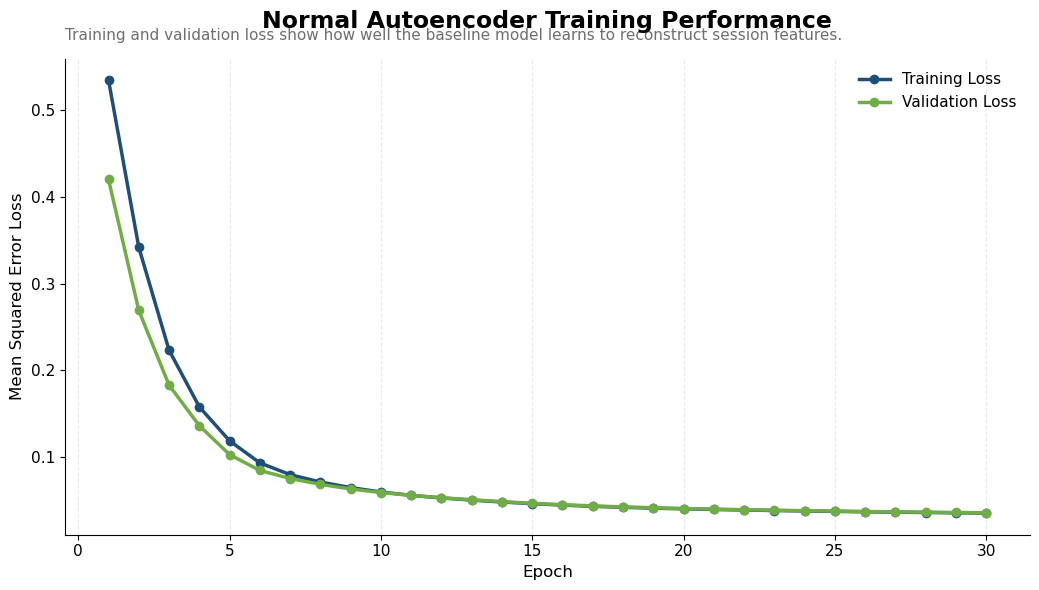

Final training loss: 0.035748
Final validation loss: 0.036117


In [13]:
# ============================================================
# Normal Autoencoder Training Loss Chart
# ============================================================

normal_loss = pd.DataFrame(normal_history.history)
normal_loss["Epoch"] = range(1, len(normal_loss) + 1)

fig, ax = plt.subplots(figsize=(10.5, 6))

ax.plot(
    normal_loss["Epoch"],
    normal_loss["loss"],
    marker="o",
    linewidth=2.5,
    label="Training Loss",
    color=COLOR_PRIMARY
)

ax.plot(
    normal_loss["Epoch"],
    normal_loss["val_loss"],
    marker="o",
    linewidth=2.5,
    label="Validation Loss",
    color=COLOR_SECONDARY
)

format_chart(
    ax=ax,
    title="Normal Autoencoder Training Performance",
    subtitle="Training and validation loss show how well the baseline model learns to reconstruct session features.",
    xlabel="Epoch",
    ylabel="Mean Squared Error Loss"
)

ax.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

print("Final training loss:", round(normal_loss["loss"].iloc[-1], 6))
print("Final validation loss:", round(normal_loss["val_loss"].iloc[-1], 6))

### Normal Autoencoder Training — Conclusion

The normal autoencoder trained successfully.

The training and validation loss both decreased strongly during the early epochs and then became stable.

This shows that the model learned to reconstruct the online shopping session features.

The training and validation curves stayed close to each other, which suggests that the model is not strongly overfitting.

This model is our baseline.  
Next, we build a sparse autoencoder and check whether it can learn a more compact bottleneck representation.

## 11. Build the Sparse Autoencoder

Now we build the sparse autoencoder.

The architecture is almost the same as the normal autoencoder.

The key difference is this:

`activity_regularizer=regularizers.l1(...)`

This adds a small penalty when bottleneck neurons are active.

### Simple meaning

The sparse autoencoder is encouraged to use fewer active bottleneck neurons.

| Model | Bottleneck behaviour |
|---|---|
| Normal autoencoder | Can freely use many bottleneck neurons |
| Sparse autoencoder | Is encouraged to keep many neurons close to zero |

This helps us test whether the model can reconstruct session behaviour using a cleaner and more compact hidden representation.

In [14]:
# ============================================================
# Build Sparse Autoencoder
# ============================================================

sparsity_strength = 1e-4

# Input layer: one preprocessed website session
input_layer = keras.Input(shape=(input_dim,), name="session_input")

# Encoder: learns hidden session behaviour features
x = layers.Dense(32, activation="relu", name="encoder_dense_32")(input_layer)

# Sparse bottleneck:
# activity_regularizer adds a penalty when too many bottleneck neurons are active.

sparse_bottleneck = layers.Dense(
    bottleneck_dim,
    activation="relu",
    activity_regularizer=regularizers.l1(sparsity_strength),
    name="sparse_bottleneck"
)(x)

# Decoder: reconstructs the original session feature vector

x = layers.Dense(32, activation="relu", name="decoder_dense_32")(sparse_bottleneck)

# Output: reconstructed session features

output_layer = layers.Dense(input_dim, activation="linear", name="reconstructed_session")(x)

# Full sparse autoencoder

sparse_autoencoder = keras.Model(
    inputs=input_layer,
    outputs=output_layer,
    name="sparse_autoencoder"
)

# Separate sparse encoder for bottleneck activity analysis
sparse_encoder = keras.Model(
    inputs=input_layer,
    outputs=sparse_bottleneck,
    name="sparse_encoder"
)

sparse_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

sparse_autoencoder.summary()

Model: "sparse_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ session_input (InputLayer)      │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_32 (Dense)        │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sparse_bottleneck (Dense)       │ (None, 12)             │           396 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_32 (Dense)        │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_session (Dense)   │ (None, 28)             │           924 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,664 (10.41 KB)

 Trainable params: 2,664 (10.41 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Train the Sparse Autoencoder

We now train the sparse autoencoder.

It uses the same input and target:

`X_train → sparse_autoencoder → reconstructed X_train`

The difference is the bottleneck layer.

The sparse model has an **L1 activity regularizer**, which encourages many bottleneck neuron values to stay close to zero.

This helps us check whether the model can reconstruct session behaviour using fewer active hidden signals.

In [15]:
# ============================================================
# Train Sparse Autoencoder
# ============================================================

sparse_history = sparse_autoencoder.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=128,
    shuffle=True,
    validation_data=(X_val, X_val),
    verbose=0
)

print("Sparse autoencoder training completed.")
print("Final training loss:", round(sparse_history.history["loss"][-1], 6))
print("Final validation loss:", round(sparse_history.history["val_loss"][-1], 6))

Sparse autoencoder training completed.
Final training loss: 0.046983
Final validation loss: 0.045389


### Sparse Autoencoder Training — Conclusion

The sparse autoencoder trained successfully.

Final sparse autoencoder results:

| Metric | Value |
|---|---:|
| Training loss | 0.046983 |
| Validation loss | 0.045389 |

The training and validation losses are close, which suggests that the model is not strongly overfitting.

Next, we compare the normal autoencoder and sparse autoencoder training curves.

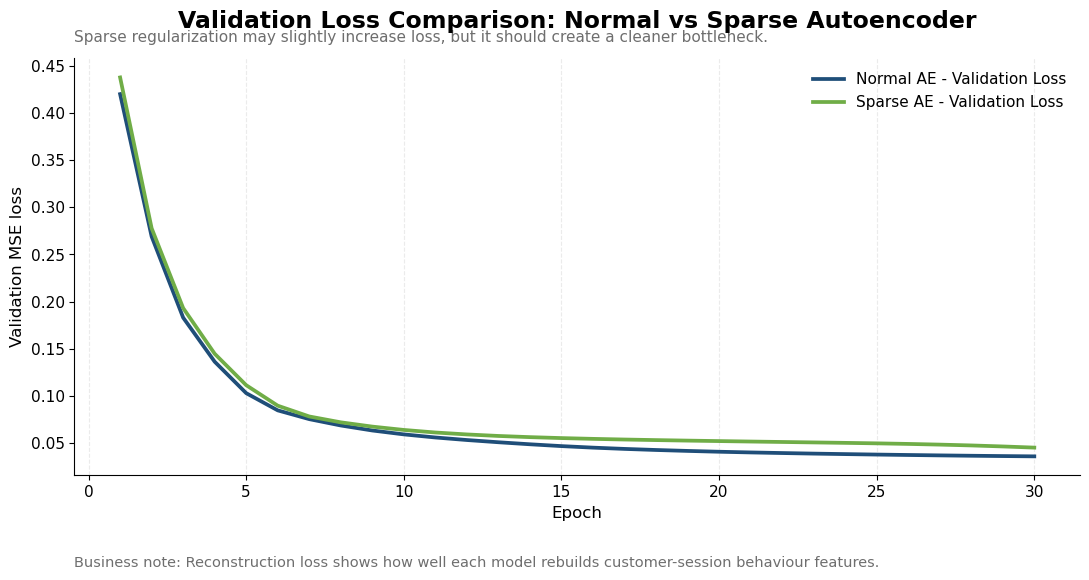

Normal AE final validation loss: 0.036117
Sparse AE final validation loss: 0.045389


In [16]:
# ============================================================
# Compare Normal and Sparse Autoencoder Training Curves
# ============================================================

normal_loss = pd.DataFrame(normal_history.history)
sparse_loss = pd.DataFrame(sparse_history.history)

normal_loss["Epoch"] = range(1, len(normal_loss) + 1)
sparse_loss["Epoch"] = range(1, len(sparse_loss) + 1)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    normal_loss["Epoch"],
    normal_loss["val_loss"],
    linewidth=2.7,
    label="Normal AE - Validation Loss",
    color=COLOR_PRIMARY
)

ax.plot(
    sparse_loss["Epoch"],
    sparse_loss["val_loss"],
    linewidth=2.7,
    label="Sparse AE - Validation Loss",
    color=COLOR_SECONDARY
)

format_chart(
    ax=ax,
    title="Validation Loss Comparison: Normal vs Sparse Autoencoder",
    subtitle="Sparse regularization may slightly increase loss, but it should create a cleaner bottleneck.",
    xlabel="Epoch",
    ylabel="Validation MSE loss"
)

ax.legend(frameon=False, fontsize=11)

ax.text(
    0,
    -0.22,
    "Business note: Reconstruction loss shows how well each model rebuilds customer-session behaviour features.",
    transform=ax.transAxes,
    fontsize=10.5,
    color=COLOR_GREY
)

plt.tight_layout()
plt.show()

print("Normal AE final validation loss:", round(normal_loss["val_loss"].iloc[-1], 6))
print("Sparse AE final validation loss:", round(sparse_loss["val_loss"].iloc[-1], 6))

### Validation Loss Comparison — Conclusion

The normal autoencoder achieved a lower validation reconstruction loss:

| Model | Final Validation Loss |
|---|---:|
| Normal Autoencoder | 0.036117 |
| Sparse Autoencoder | 0.045389 |

This means the normal autoencoder reconstructed the session features better.

The sparse autoencoder had a slightly higher validation loss because it was forced to keep many bottleneck activations closer to zero.

This shows the expected trade-off:

- **Normal Autoencoder:** better reconstruction
- **Sparse Autoencoder:** simpler and more compact bottleneck representation

Next, we check whether the sparse model really used fewer active bottleneck neurons.

In [17]:
# ============================================================
# Compare Bottleneck Activity
# ============================================================

# Get bottleneck outputs for validation data

normal_bottleneck_values = normal_encoder.predict(X_val, verbose=0)
sparse_bottleneck_values = sparse_encoder.predict(X_val, verbose=0)

# Average activation: lower means less neuron activity

normal_avg_activation = np.mean(normal_bottleneck_values)
sparse_avg_activation = np.mean(sparse_bottleneck_values)

# Near-zero percentage: higher means more sparse behaviour

threshold = 0.01

normal_near_zero = np.mean(normal_bottleneck_values < threshold) * 100
sparse_near_zero = np.mean(sparse_bottleneck_values < threshold) * 100

bottleneck_summary = pd.DataFrame({
    "Model": ["Normal Autoencoder", "Sparse Autoencoder"],
    "Average Bottleneck Activation": [normal_avg_activation, sparse_avg_activation],
    "Near-Zero Activations %": [normal_near_zero, sparse_near_zero]
})

bottleneck_summary

,Model,Average Bottleneck Activation,Near-Zero Activations %
0,Normal Autoencoder,2.487932,0.198305
1,Sparse Autoencoder,1.762660,0.585902


### Bottleneck Activity — Interpretation

The sparse autoencoder reduced the average bottleneck activation.

| Model | Average Bottleneck Activation | Near-Zero Activations |
|---|---:|---:|
| Normal Autoencoder | 2.4879 | 0.20% |
| Sparse Autoencoder | 1.7627 | 0.59% |

This means the sparse autoencoder used the bottleneck less aggressively than the normal autoencoder.

The near-zero activation percentage also increased, which shows that the sparse regularisation started pushing more neuron values closer to zero.

However, the sparsity is still moderate, not extreme.

This is acceptable because we used a small L1 regularisation strength. A stronger L1 value would create more sparsity, but it may also increase reconstruction loss.

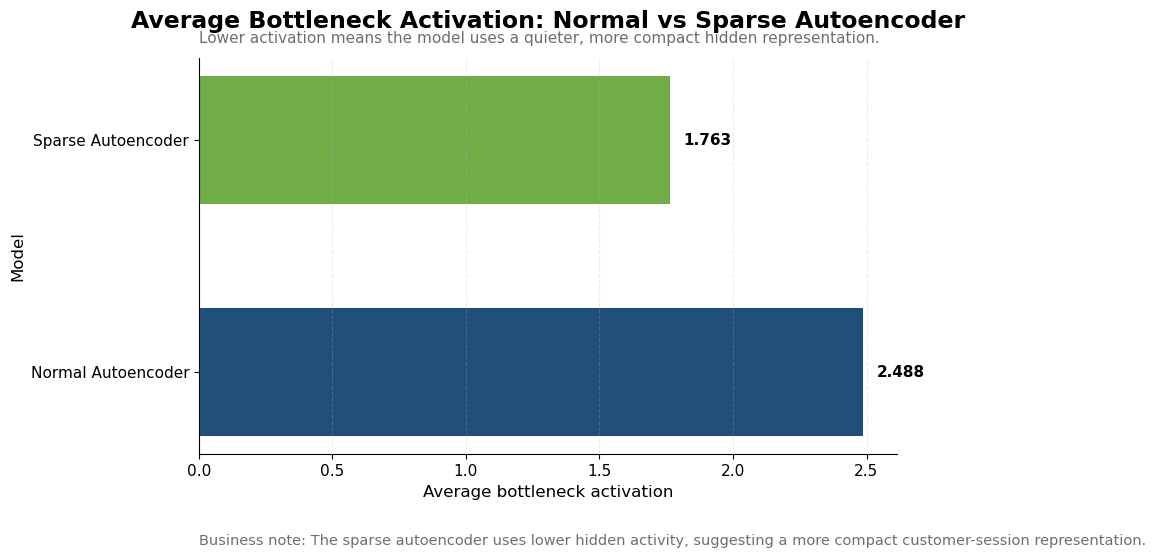

In [18]:
# ============================================================
# Bottleneck Activity Comparison Chart
# ============================================================

activity_chart = bottleneck_summary.copy()

fig, ax = plt.subplots(figsize=(10.5, 5.8))

bars = ax.barh(
    activity_chart["Model"],
    activity_chart["Average Bottleneck Activation"],
    color=[COLOR_PRIMARY, COLOR_SECONDARY],
    height=0.55
)

for bar, value in zip(bars, activity_chart["Average Bottleneck Activation"]):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

format_chart(
    ax=ax,
    title="Average Bottleneck Activation: Normal vs Sparse Autoencoder",
    subtitle="Lower activation means the model uses a quieter, more compact hidden representation.",
    xlabel="Average bottleneck activation",
    ylabel="Model"
)

ax.text(
    0,
    -0.23,
    "Business note: The sparse autoencoder uses lower hidden activity, suggesting a more compact customer-session representation.",
    transform=ax.transAxes,
    fontsize=10.5,
    color=COLOR_GREY
)

plt.tight_layout()
plt.show()

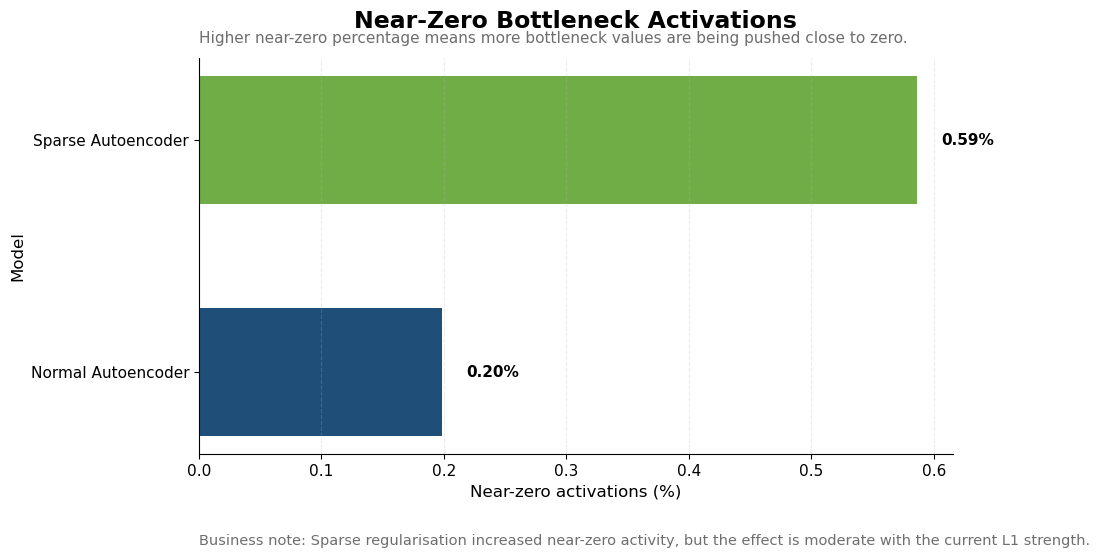

In [19]:
# ============================================================
# Near-Zero Bottleneck Activation Chart
# ============================================================

fig, ax = plt.subplots(figsize=(10.5, 5.8))

bars = ax.barh(
    activity_chart["Model"],
    activity_chart["Near-Zero Activations %"],
    color=[COLOR_PRIMARY, COLOR_SECONDARY],
    height=0.55
)

for bar, value in zip(bars, activity_chart["Near-Zero Activations %"]):
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

format_chart(
    ax=ax,
    title="Near-Zero Bottleneck Activations",
    subtitle="Higher near-zero percentage means more bottleneck values are being pushed close to zero.",
    xlabel="Near-zero activations (%)",
    ylabel="Model"
)

ax.text(
    0,
    -0.23,
    "Business note: Sparse regularisation increased near-zero activity, but the effect is moderate with the current L1 strength.",
    transform=ax.transAxes,
    fontsize=10.5,
    color=COLOR_GREY
)

plt.tight_layout()
plt.show()

### Bottleneck Activity Comparison — Conclusion

The bottleneck activity comparison helps us check whether the sparse autoencoder actually learned a more compact hidden representation.

| Model | Average Bottleneck Activation | Near-Zero Activations |
|---|---:|---:|
| Normal Autoencoder | 2.4879 | 0.20% |
| Sparse Autoencoder | 1.7627 | 0.59% |

---

#### What changed?

The sparse autoencoder reduced the average bottleneck activation from **2.4879** to **1.7627**.

This means the sparse model used its hidden bottleneck neurons less strongly than the normal autoencoder.

The near-zero activation percentage also increased from **0.20%** to **0.59%**.

This means more bottleneck values were pushed closer to zero.

---

#### Why this matters

The bottleneck is the compressed behaviour summary of each website session.

A normal autoencoder may reconstruct well by using many bottleneck neurons strongly.

A sparse autoencoder tries to reconstruct the data while keeping many bottleneck values smaller or closer to zero.

This is useful because it can create a cleaner and more compact representation of customer behaviour.

In business terms, this can help reduce many raw website-session features into fewer useful behaviour signals.

These hidden behaviour signals may later support:

| Use case | Example |
|---|---|
| Customer segmentation | Group sessions by similar behaviour patterns |
| Anomaly detection | Find unusual website sessions |
| Purchase-behaviour analysis | Compare buyer and non-buyer session patterns |
| Feature extraction | Create compact features for later models |

---

#### Final interpretation

The sparse autoencoder became more compact than the normal autoencoder.

However, the sparsity effect is moderate, not extreme.

This makes sense because we used a small L1 regularisation strength. A stronger L1 value could create more sparsity, but it may also increase reconstruction error.

## 14. Evaluate Reconstruction Error on Test Data

We now evaluate both autoencoders on the final test set.

The test set was not used during training or validation, so it gives the cleanest final performance check.

Both models try to reconstruct the same input features:

`X_test → autoencoder → reconstructed X_test`

We compare the reconstruction error for:

| Model | What it tells us |
|---|---|
| Normal Autoencoder | Final reconstruction quality without sparsity |
| Sparse Autoencoder | Final reconstruction quality with bottleneck sparsity |

This helps us understand the trade-off between reconstruction quality and compact hidden representation.

In [22]:
# ============================================================
# Test Reconstruction Error: Normal vs Sparse Autoencoder
# ============================================================

# Predict reconstructed session features on unseen test data
normal_test_reconstruction = normal_autoencoder.predict(X_test, verbose=0)
sparse_test_reconstruction = sparse_autoencoder.predict(X_test, verbose=0)

# Calculate reconstruction error for each test session
normal_test_error = np.mean(np.square(X_test - normal_test_reconstruction), axis=1)
sparse_test_error = np.mean(np.square(X_test - sparse_test_reconstruction), axis=1)

# Summarise average and median reconstruction error
test_error_summary = pd.DataFrame({
    "Model": ["Normal Autoencoder", "Sparse Autoencoder"],
    "Average Test Reconstruction Error": [
        normal_test_error.mean(),
        sparse_test_error.mean()
    ],
    "Median Test Reconstruction Error": [
        np.median(normal_test_error),
        np.median(sparse_test_error)
    ]
})

test_error_summary.round(6)

,Model,Average Test Reconstruction Error,Median Test Reconstruction Error
0,Normal Autoencoder,0.034884,0.031021
1,Sparse Autoencoder,0.043283,0.035930


### Test Reconstruction Error — Conclusion

Both autoencoders were evaluated on the final test set.

| Model | Average Test Reconstruction Error | Median Test Reconstruction Error |
|---|---:|---:|
| Normal Autoencoder | 0.034884 | 0.031021 |
| Sparse Autoencoder | 0.043283 | 0.035930 |

The **normal autoencoder** achieved the lower reconstruction error.

This means it reconstructed unseen website-session features more accurately.

The **sparse autoencoder** had a higher reconstruction error because it was encouraged to use a simpler bottleneck representation.

This confirms the expected sparse autoencoder trade-off:

| Model | Strength |
|---|---|
| Normal Autoencoder | Better reconstruction quality |
| Sparse Autoencoder | More compact hidden representation |

In business terms, the normal autoencoder is better if the goal is to reconstruct session data as accurately as possible.

The sparse autoencoder is useful if the goal is to learn simpler hidden behaviour signals that may support later analysis such as segmentation, anomaly detection, or behaviour pattern discovery.

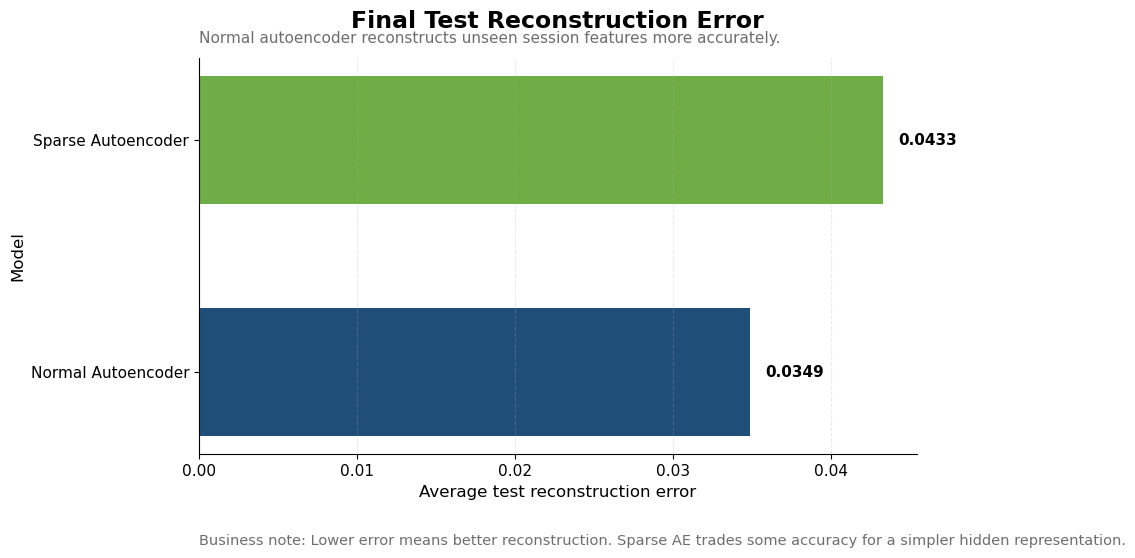

In [23]:
# ============================================================
# Test Reconstruction Error Comparison Chart
# ============================================================

test_error_chart = test_error_summary.copy()

fig, ax = plt.subplots(figsize=(10.5, 5.8))

bars = ax.barh(
    test_error_chart["Model"],
    test_error_chart["Average Test Reconstruction Error"],
    color=[COLOR_PRIMARY, COLOR_SECONDARY],
    height=0.55
)

for bar, value in zip(bars, test_error_chart["Average Test Reconstruction Error"]):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

format_chart(
    ax=ax,
    title="Final Test Reconstruction Error",
    subtitle="Normal autoencoder reconstructs unseen session features more accurately.",
    xlabel="Average test reconstruction error",
    ylabel="Model"
)

ax.text(
    0,
    -0.23,
    "Business note: Lower error means better reconstruction. Sparse AE trades some accuracy for a simpler hidden representation.",
    transform=ax.transAxes,
    fontsize=10.5,
    color=COLOR_GREY
)

plt.tight_layout()
plt.show()

### Test Reconstruction Error Chart — Conclusion

The final test reconstruction error confirms the same pattern seen during validation.

The **normal autoencoder** achieved a lower average test reconstruction error:

| Model | Average Test Reconstruction Error |
|---|---:|
| Normal Autoencoder | 0.0349 |
| Sparse Autoencoder | 0.0433 |

This means the normal autoencoder reconstructed unseen website-session features more accurately.

The sparse autoencoder produced a higher reconstruction error because it was trained with a sparsity rule in the bottleneck.

This confirms the main trade-off:

| Model | Main strength |
|---|---|
| Normal Autoencoder | Better reconstruction accuracy |
| Sparse Autoencoder | More compact hidden representation |

In business terms, the normal autoencoder is better when the goal is accurate reconstruction.

The sparse autoencoder is useful when the goal is to learn simpler hidden behaviour signals that may support later analysis, such as segmentation, anomaly detection, or purchase-pattern exploration.

# PCA

In [24]:
# PCA will reduce 12 bottleneck values into 2 chart dimensions
from sklearn.decomposition import PCA

## 15. Visualise Sparse Bottleneck Features

The sparse encoder compresses each website session into **12 bottleneck values**.

To visualise these hidden features, we use **PCA**.

PCA reduces the 12 bottleneck values into 2 dimensions so we can plot them.

We colour the points using **Revenue**:

| Colour group | Meaning |
|---|---|
| No Purchase | Session did not end in purchase |
| Purchase | Session ended in purchase |

This helps us check whether purchase and non-purchase sessions show different hidden behaviour patterns.

In [25]:
# ============================================================
# Create PCA Data from Sparse Bottleneck Features
# ============================================================

# Source: sparse_encoder converts test sessions into 12 bottleneck values
sparse_test_bottleneck = sparse_encoder.predict(X_test, verbose=0)

# PCA reduces 12 bottleneck values into 2 dimensions for visualisation
pca = PCA(n_components=2, random_state=42)
sparse_pca_values = pca.fit_transform(sparse_test_bottleneck)

# Create clean plotting table
pca_plot_data = pd.DataFrame({
    "PCA 1": sparse_pca_values[:, 0],
    "PCA 2": sparse_pca_values[:, 1],
    "Revenue": test_revenue.values
})

pca_plot_data["Revenue Label"] = pca_plot_data["Revenue"].map({
    False: "No Purchase",
    True: "Purchase"
})

print("Sparse bottleneck shape:", sparse_test_bottleneck.shape)
print("PCA plot data shape:", pca_plot_data.shape)
print("Explained variance by PCA 1 and PCA 2:", np.round(pca.explained_variance_ratio_, 4))

Sparse bottleneck shape: (1850, 12)
PCA plot data shape: (1850, 4)
Explained variance by PCA 1 and PCA 2: [0.5086 0.134 ]


### Sparse Bottleneck PCA Preparation — Conclusion

The sparse encoder compressed each test session into **12 bottleneck values**.

PCA was then used to reduce these 12 values into **2 visual dimensions**.

| PCA Component | Explained Variance |
|---|---:|
| PCA 1 | 50.86% |
| PCA 2 | 13.40% |

Together, the first two PCA components explain **64.26%** of the sparse bottleneck information.

This means the 2D plot will show a useful summary of the hidden behaviour space, although it will not capture every detail from the full 12-dimensional bottleneck.

Next, we visualise the sparse bottleneck space and colour the sessions by purchase outcome.

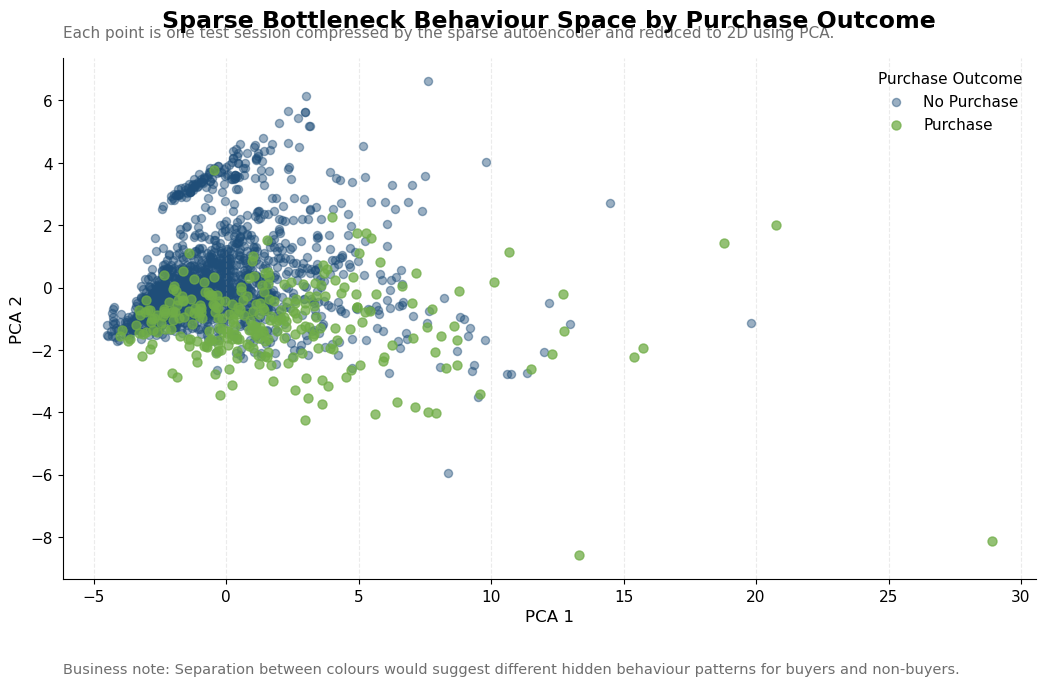

In [26]:
# ============================================================
# Sparse Bottleneck PCA Scatter Plot
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7))

# Plot no-purchase sessions first
no_purchase_data = pca_plot_data[pca_plot_data["Revenue Label"] == "No Purchase"]
purchase_data = pca_plot_data[pca_plot_data["Revenue Label"] == "Purchase"]

ax.scatter(
    no_purchase_data["PCA 1"],
    no_purchase_data["PCA 2"],
    s=34,
    alpha=0.45,
    color=COLOR_PRIMARY,
    label="No Purchase"
)

ax.scatter(
    purchase_data["PCA 1"],
    purchase_data["PCA 2"],
    s=42,
    alpha=0.75,
    color=COLOR_SECONDARY,
    label="Purchase"
)

format_chart(
    ax=ax,
    title="Sparse Bottleneck Behaviour Space by Purchase Outcome",
    subtitle="Each point is one test session compressed by the sparse autoencoder and reduced to 2D using PCA.",
    xlabel="PCA 1",
    ylabel="PCA 2"
)

ax.legend(
    title="Purchase Outcome",
    frameon=False,
    fontsize=11,
    title_fontsize=11,
    loc="best"
)

ax.text(
    0,
    -0.18,
    "Business note: Separation between colours would suggest different hidden behaviour patterns for buyers and non-buyers.",
    transform=ax.transAxes,
    fontsize=10.5,
    color=COLOR_GREY
)

plt.tight_layout()
plt.show()

### Sparse Bottleneck PCA Plot — Conclusion

The PCA plot visualises the sparse autoencoder's hidden behaviour space.

Each point represents one test session.

| Colour | Meaning |
|---|---|
| Blue | No purchase session |
| Green | Purchase session |

---

#### What the plot shows

Most no-purchase sessions are concentrated in the dense left and middle area of the plot.

Purchase sessions are more spread out and appear more often toward the right and lower-right areas.

This suggests that some purchase sessions have different hidden behaviour patterns compared with many non-purchase sessions.

---

#### Important note

The separation is not perfect.

There is still overlap between purchase and non-purchase sessions.

This is expected because the sparse autoencoder was not trained to classify purchase outcome.

It was trained only to reconstruct session behaviour features.

Revenue was used only after training to colour the plot for interpretation.

---

#### Business interpretation

The plot suggests that the sparse bottleneck features contain useful behavioural information.

Some buyer sessions appear to follow different hidden behaviour patterns from many non-buyer sessions.

This means the learned bottleneck features could be useful later for:

| Use case | How it could help |
|---|---|
| Customer segmentation | Group sessions with similar hidden behaviour |
| Purchase behaviour analysis | Compare buyer and non-buyer patterns |
| Anomaly detection | Identify sessions far away from common behaviour |
| Feature engineering | Use bottleneck features in later predictive models |

---

#### Final takeaway

The sparse autoencoder did not create a perfect buyer/non-buyer split.

However, it learned a hidden behaviour space where some purchase-related patterns are visible.

## 16. Business Insight Charts from Sparse Bottleneck Features

So far, we proved that the sparse autoencoder learned a compact hidden representation.

Now we use that hidden representation for business interpretation.

The sparse bottleneck features can help answer practical questions such as:

| Business Question | How We Check It |
|---|---|
| Can we group similar website sessions? | Cluster sessions using bottleneck features |
| Do hidden segments have different purchase rates? | Compare purchase rate by segment |
| Are some sessions unusual? | Check high reconstruction error sessions |
| Can bottleneck values become new features? | Create compact features for future models |

In this section, we use the sparse bottleneck output as a behaviour summary of each session.

In [27]:
# ============================================================
# Create Behaviour Segments from Sparse Bottleneck Features
# ============================================================

from sklearn.cluster import KMeans

# Source:
#   sparse_test_bottleneck contains 12 hidden values per test session.

# Logic:
#   KMeans groups sessions with similar hidden behaviour patterns.

number_of_segments = 4

kmeans = KMeans(
    n_clusters=number_of_segments,
    random_state=42,
    n_init=10
)

# Each test session receives one segment label

segment_labels = kmeans.fit_predict(sparse_test_bottleneck)

# Add segment labels to PCA plotting data

pca_plot_data["Segment"] = segment_labels
pca_plot_data["Segment Label"] = pca_plot_data["Segment"].apply(lambda x: f"Segment {x + 1}")

print("Behaviour segments created successfully.")
print("Number of segments:", number_of_segments)
print("\nSegment counts:")
print(pca_plot_data["Segment Label"].value_counts().sort_index())

Behaviour segments created successfully.
Number of segments: 4

Segment counts:
Segment Label
Segment 1     354
Segment 2     403
Segment 3    1040
Segment 4      53
Name: count, dtype: int64


## Hidden Behaviour Segments from Sparse Bottleneck Features

The sparse autoencoder compressed each test session into **12 hidden bottleneck values**.

These 12 values act like a short behaviour summary for each website session.

Instead of analysing all processed input columns one by one, we can use these bottleneck values to group sessions with similar behaviour.

To do this, we used **KMeans clustering**.

KMeans groups sessions that look similar in the hidden bottleneck space.

The idea is simple:

`similar hidden behaviour → same segment`

`different hidden behaviour → different segment`

---

### What We Created

We created **4 hidden behaviour segments** from the sparse bottleneck features.

| Segment | Number of Sessions | Simple Meaning |
|---|---:|---|
| Segment 1 | 354 | Smaller behaviour group |
| Segment 2 | 403 | Medium behaviour group |
| Segment 3 | 1,040 | Most common behaviour group |
| Segment 4 | 53 | Small rare behaviour group |

---

### Why This Matters

This step helps us move from technical model output to business interpretation.

Instead of saying:

`This session has 12 bottleneck values`

we can say:

`This session belongs to Segment 1, 2, 3, or 4`

This makes the hidden features easier to understand and compare.

---

### Business Questions We Can Ask Next

| Business Question | Why It Matters |
|---|---|
| Which segment has the highest purchase rate? | Helps identify high-value behaviour patterns |
| Which segment has the lowest purchase rate? | Helps find weak or low-intent behaviour patterns |
| Which segment is very small? | May show rare or unusual session behaviour |
| Which segment has higher reconstruction error? | May point to unusual sessions or possible anomalies |
| Can these segments support future marketing analysis? | Helps connect autoencoder features to business decisions |

---

### Final Interpretation

The sparse autoencoder learned hidden behaviour features.

KMeans used those hidden features to create behaviour segments.

These segments can now be compared using business metrics such as purchase rate, session share, and reconstruction error.

This turns the sparse autoencoder from a pure technical model into a practical business analysis tool.

In [28]:
# ============================================================
# Segment Business Summary
# ============================================================

# Add sparse reconstruction error to each test session
pca_plot_data["Sparse Reconstruction Error"] = sparse_test_error

segment_summary = (
    pca_plot_data
    .groupby("Segment Label")
    .agg(
        Sessions=("Segment Label", "count"),
        Purchase_Rate=("Revenue", "mean"),
        Average_Reconstruction_Error=("Sparse Reconstruction Error", "mean")
    )
    .reset_index()
)

segment_summary["Session Share %"] = (
    segment_summary["Sessions"] / segment_summary["Sessions"].sum() * 100
)

segment_summary["Purchase Rate %"] = segment_summary["Purchase_Rate"] * 100

segment_summary = segment_summary[
    [
        "Segment Label",
        "Sessions",
        "Session Share %",
        "Purchase Rate %",
        "Average_Reconstruction_Error"
    ]
]

segment_summary.round(3)

,Segment Label,Sessions,Session Share %,Purchase Rate %,Average_Reconstruction_Error
0,Segment 1,354,19.135,1.695,0.028
1,Segment 2,403,21.784,32.258,0.057
2,Segment 3,1040,56.216,12.019,0.039
3,Segment 4,53,2.865,47.170,0.133


## 17. Visualise Hidden Behaviour Segments

We created 4 behaviour segments using the sparse autoencoder bottleneck features.

Each test session was compressed into 12 hidden values.  
Then KMeans grouped sessions with similar hidden behaviour into segments.

Now we visualise those segments in the 2D PCA space.

This helps us see whether the hidden behaviour groups form visible patterns.

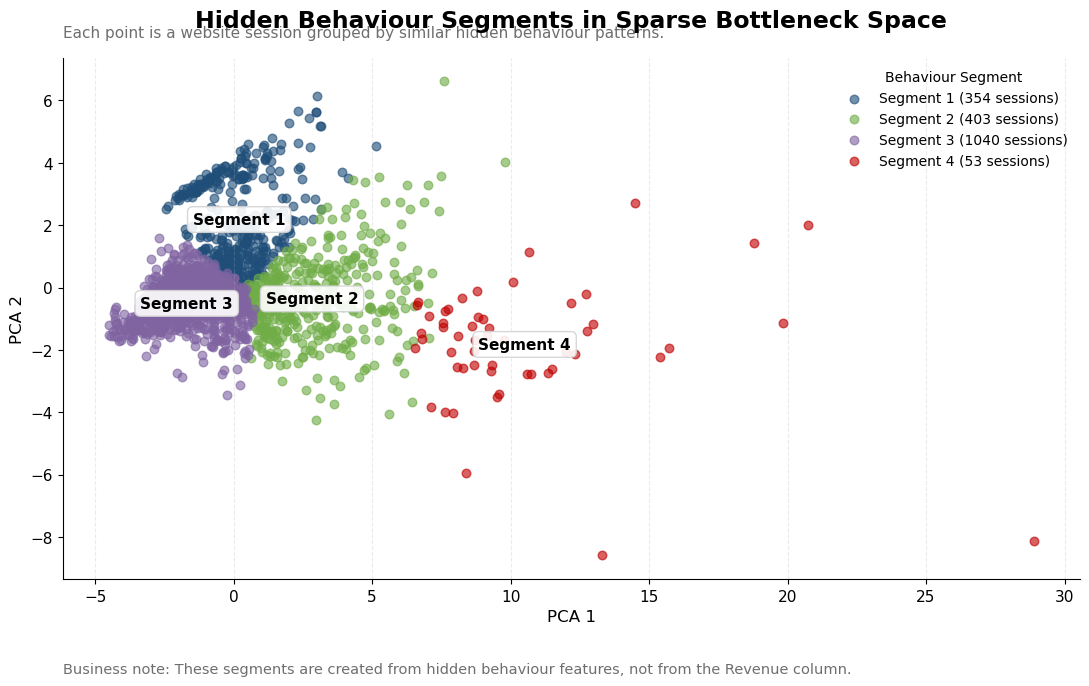

In [29]:
# ============================================================
# Visualise Hidden Behaviour Segments
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7))

segment_colors = {
    "Segment 1": COLOR_PRIMARY,
    "Segment 2": COLOR_SECONDARY,
    "Segment 3": "#8064A2",
    "Segment 4": COLOR_ACCENT
}

# Plot each segment separately for a clean legend
for segment, color in segment_colors.items():
    segment_data = pca_plot_data[pca_plot_data["Segment Label"] == segment]
    
    ax.scatter(
        segment_data["PCA 1"],
        segment_data["PCA 2"],
        s=38,
        alpha=0.62,
        color=color,
        label=f"{segment} ({len(segment_data)} sessions)"
    )

# Add segment labels near the centre of each cluster
segment_centres = (
    pca_plot_data
    .groupby("Segment Label")[["PCA 1", "PCA 2"]]
    .mean()
    .reset_index()
)

for _, row in segment_centres.iterrows():
    ax.text(
        row["PCA 1"],
        row["PCA 2"],
        row["Segment Label"],
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="lightgray", alpha=0.9)
    )

format_chart(
    ax=ax,
    title="Hidden Behaviour Segments in Sparse Bottleneck Space",
    subtitle="Each point is a website session grouped by similar hidden behaviour patterns.",
    xlabel="PCA 1",
    ylabel="PCA 2"
)

ax.legend(
    title="Behaviour Segment",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="best"
)

ax.text(
    0,
    -0.18,
    "Business note: These segments are created from hidden behaviour features, not from the Revenue column.",
    transform=ax.transAxes,
    fontsize=10.5,
    color=COLOR_GREY
)

plt.tight_layout()
plt.show()

### Hidden Behaviour Segment Visualisation — Conclusion

The hidden behaviour segment chart shows four groups created from the sparse autoencoder bottleneck features.

Each point represents one website session.

The segments were created from hidden behaviour patterns, not from the Revenue column.

| Segment | Sessions | Visual meaning |
|---|---:|---|
| Segment 1 | 354 | Smaller group with higher PCA 2 values |
| Segment 2 | 403 | Medium group spread through the centre/right area |
| Segment 3 | 1,040 | Largest and most common behaviour group |
| Segment 4 | 53 | Small rare group located far to the right |

---

#### Main insight

Segment 3 is the largest group, which means it represents the most common type of website-session behaviour in the test data.

Segment 4 is very small and visually separated from the other groups.  
This suggests it may represent unusual or less common session behaviour.

---

#### Why this matters

This chart turns the sparse autoencoder output into something easier to understand.

Instead of analysing 12 hidden bottleneck values directly, we can describe sessions using behaviour segments.

These segments can now be compared using business metrics such as:

- purchase rate,
- session share,
- reconstruction error,
- and unusual behaviour patterns.

Next, we use these segments to answer business questions.

- Segment 4 = highest purchase rate, but very small and unusual
- Segment 2 = strong purchase rate with decent size
- Segment 3 = largest group, but lower purchase rate
- Segment 1 = low purchase rate

### Hidden Behaviour Segment Summary — Business Interpretation

The segment summary shows that the hidden behaviour groups have very different business outcomes.

| Segment | Sessions | Session Share | Purchase Rate | Avg. Reconstruction Error |
|---|---:|---:|---:|---:|
| Segment 1 | 354 | 19.14% | 1.70% | 0.028 |
| Segment 2 | 403 | 21.78% | 32.26% | 0.057 |
| Segment 3 | 1,040 | 56.22% | 12.02% | 0.039 |
| Segment 4 | 53 | 2.87% | 47.17% | 0.133 |

---

#### Key Business Findings

**Segment 4** has the highest purchase rate at **47.17%**, but it is very small, with only **53 sessions**.

This segment may represent rare but high-value behaviour.

**Segment 2** is also important because it has a strong purchase rate of **32.26%** and a larger session count of **403 sessions**.

This makes Segment 2 more commercially useful than Segment 4 because it combines better volume with high purchase intent.

**Segment 3** is the largest group, covering **56.22%** of test sessions, but its purchase rate is only **12.02%**.

This may represent common browsing behaviour with moderate purchase intent.

**Segment 1** has the lowest purchase rate at **1.70%**, which may represent low-intent or weak engagement sessions.

---

#### Business Meaning

The sparse autoencoder created hidden behaviour segments that show different purchase patterns.

This means the bottleneck features are not just technical outputs.

They can support business analysis by helping identify:

- high-value behaviour groups,
- low-intent visitor groups,
- common browsing patterns,
- and rare unusual sessions.

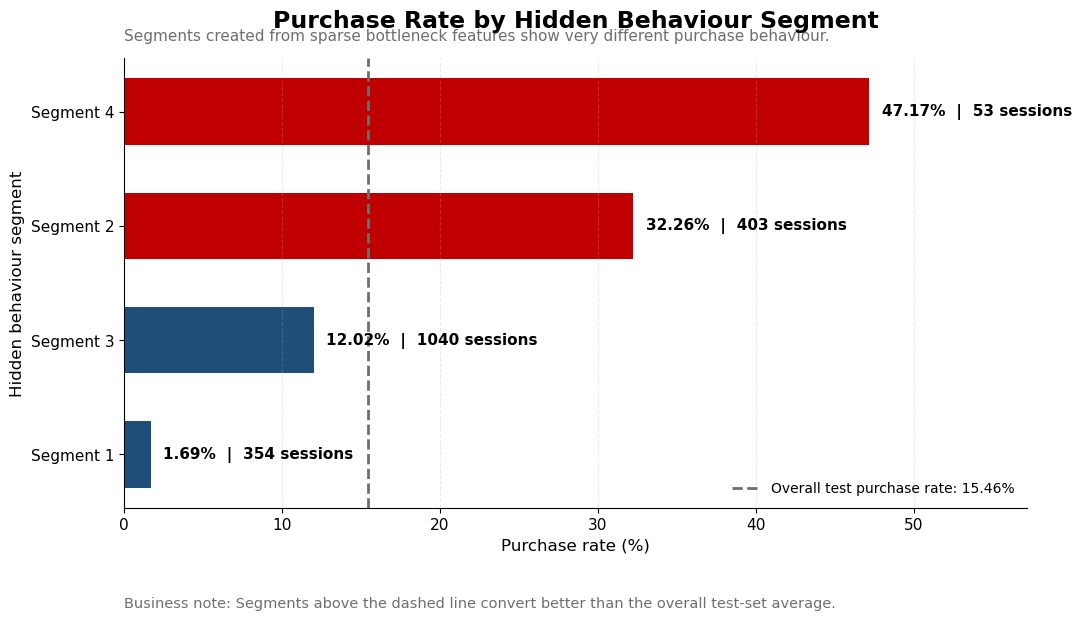

In [30]:
# ============================================================
# BI Chart: Purchase Rate by Hidden Behaviour Segment
# ============================================================

purchase_segment_chart = segment_summary.sort_values("Purchase Rate %", ascending=True)
overall_purchase_rate = test_revenue.mean() * 100

fig, ax = plt.subplots(figsize=(11, 6.4))

bar_colors = [
    COLOR_ACCENT if rate >= overall_purchase_rate else COLOR_PRIMARY
    for rate in purchase_segment_chart["Purchase Rate %"]
]

bars = ax.barh(
    purchase_segment_chart["Segment Label"],
    purchase_segment_chart["Purchase Rate %"],
    color=bar_colors,
    height=0.58
)

# Overall purchase rate reference line
ax.axvline(
    overall_purchase_rate,
    color=COLOR_GREY,
    linestyle="--",
    linewidth=2,
    label=f"Overall test purchase rate: {overall_purchase_rate:.2f}%"
)

# Value labels
for bar, rate, sessions in zip(
    bars,
    purchase_segment_chart["Purchase Rate %"],
    purchase_segment_chart["Sessions"]
):
    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.2f}%  |  {sessions} sessions",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

format_chart(
    ax=ax,
    title="Purchase Rate by Hidden Behaviour Segment",
    subtitle="Segments created from sparse bottleneck features show very different purchase behaviour.",
    xlabel="Purchase rate (%)",
    ylabel="Hidden behaviour segment"
)

ax.legend(frameon=False, fontsize=10)

ax.text(
    0,
    -0.22,
    "Business note: Segments above the dashed line convert better than the overall test-set average.",
    transform=ax.transAxes,
    fontsize=10.5,
    color=COLOR_GREY
)

ax.set_xlim(0, purchase_segment_chart["Purchase Rate %"].max() + 10)

plt.tight_layout()
plt.show()

### Purchase Rate by Segment — Conclusion

The purchase rate chart shows that the hidden behaviour segments have very different conversion behaviour.

**Segment 4** has the highest purchase rate at **47.17%**, but it is a very small segment.

**Segment 2** is especially important because it has a high purchase rate of **32.26%** and a stronger session volume than Segment 4.

**Segment 3** is the largest segment, but its purchase rate is only **12.02%**.

**Segment 1** has the weakest purchase behaviour, with only **1.70%** purchase rate.

---

#### Business takeaway

The sparse autoencoder helped create behaviour groups that separate low-intent, common browsing, and high-intent sessions.

This is useful for digital marketing because different segments may need different actions:

| Segment | Possible Business Action |
|---|---|
| Segment 1 | Improve engagement or retarget carefully |
| Segment 2 | Prioritise for conversion campaigns |
| Segment 3 | Analyse common browsing behaviour |
| Segment 4 | Investigate rare high-value behaviour |

Which hidden segment is most commercially attractive?

## 18. Segment Size vs Purchase Rate

Now we compare two business metrics together:

| Metric | Meaning |
|---|---|
| **Session Share %** | How large the segment is |
| **Purchase Rate %** | How strongly the segment converts |

This helps us identify which hidden behaviour segments are commercially useful.

A strong segment should ideally have:

- good purchase rate,
- enough session volume,
- and clear behaviour meaning.

This chart helps separate small rare segments from larger high-value segments.

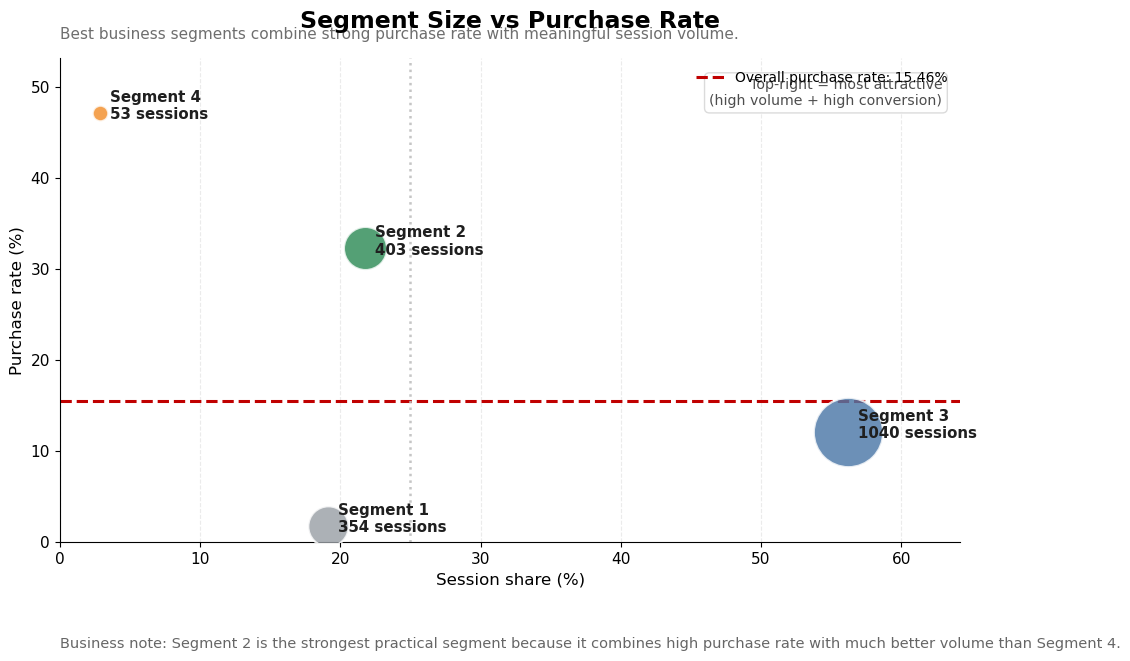

In [32]:
# ============================================================
# BI Chart: Segment Size vs Purchase Rate (Improved Design)
# ============================================================

fig, ax = plt.subplots(figsize=(11.5, 6.8))

# Business-driven colors
segment_color_map = {
    "Segment 1": "#9AA0A6",   # muted grey = weak performer
    "Segment 2": "#2E8B57",   # green = strong actionable segment
    "Segment 3": "#4C78A8",   # blue = largest/common segment
    "Segment 4": "#F28E2B"    # orange = rare but high-value segment
}

# Bubble size based on number of sessions
bubble_sizes = segment_summary["Sessions"] * 2.4

# Plot each segment separately so colors are controlled cleanly
for _, row in segment_summary.iterrows():
    ax.scatter(
        row["Session Share %"],
        row["Purchase Rate %"],
        s=row["Sessions"] * 2.4,
        color=segment_color_map[row["Segment Label"]],
        alpha=0.82,
        edgecolor="white",
        linewidth=1.6,
        zorder=3
    )

# Clean labels
for _, row in segment_summary.iterrows():
    ax.text(
        row["Session Share %"] + 0.7,
        row["Purchase Rate %"] + 0.8,
        f'{row["Segment Label"]}\n{int(row["Sessions"])} sessions',
        fontsize=10.8,
        fontweight="bold",
        ha="left",
        va="center",
        color="#1f1f1f"
    )

# Overall purchase-rate reference line
overall_purchase_rate = test_revenue.mean() * 100

ax.axhline(
    overall_purchase_rate,
    color="#C00000",
    linestyle="--",
    linewidth=2.2,
    label=f"Overall purchase rate: {overall_purchase_rate:.2f}%"
)

# Optional vertical reference line for average segment size
average_session_share = segment_summary["Session Share %"].mean()
ax.axvline(
    average_session_share,
    color="#BFBFBF",
    linestyle=":",
    linewidth=1.8,
    alpha=0.9
)

# Chart formatting
format_chart(
    ax=ax,
    title="Segment Size vs Purchase Rate",
    subtitle="Best business segments combine strong purchase rate with meaningful session volume.",
    xlabel="Session share (%)",
    ylabel="Purchase rate (%)"
)

# Highlight useful business regions
ax.text(
    0.98, 0.96,
    "Top-right = most attractive\n(high volume + high conversion)",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10.2,
    color="#4d4d4d",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#D9D9D9", alpha=0.95)
)

ax.legend(frameon=False, fontsize=10, loc="upper right")

ax.text(
    0,
    -0.22,
    "Business note: Segment 2 is the strongest practical segment because it combines high purchase rate with much better volume than Segment 4.",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#666666"
)

# Limits
ax.set_xlim(0, segment_summary["Session Share %"].max() + 8)
ax.set_ylim(0, segment_summary["Purchase Rate %"].max() + 6)

plt.tight_layout()
plt.show()

### Segment Size vs Purchase Rate — Conclusion

This chart compares two important business metrics together:

- **Session share (%)** → how large the segment is
- **Purchase rate (%)** → how strongly the segment converts

The color design highlights the business meaning of each segment.

| Segment | Interpretation |
|---|---|
| **Segment 2** | Strongest practical segment: high purchase rate and good volume |
| **Segment 4** | Highest purchase rate, but very small niche segment |
| **Segment 3** | Largest segment, but only moderate purchase performance |
| **Segment 1** | Lower-value segment with very weak purchase behaviour |

#### Main takeaway

**Segment 2** is the most actionable business segment.

It has:
- a strong purchase rate,
- a meaningful number of sessions,
- and much better scale than Segment 4.

**Segment 4** is still important, but it is a small special-case segment.

This means the sparse autoencoder helped identify not just different technical clusters, but different commercial opportunity groups.

Which hidden behaviour segments are unusual or harder for the sparse autoencoder to reconstruct?

## 19. Reconstruction Error by Hidden Behaviour Segment

Now we compare the average reconstruction error for each hidden behaviour segment.

Reconstruction error means:

`original session features - reconstructed session features`

A higher error means the model had more difficulty rebuilding that session behaviour.

This can help us identify unusual or less common behaviour patterns.

| Lower error | Higher error |
|---|---|
| More typical behaviour | More unusual behaviour |
| Easier to reconstruct | Harder to reconstruct |
| Common session pattern | Possible anomaly-like pattern |

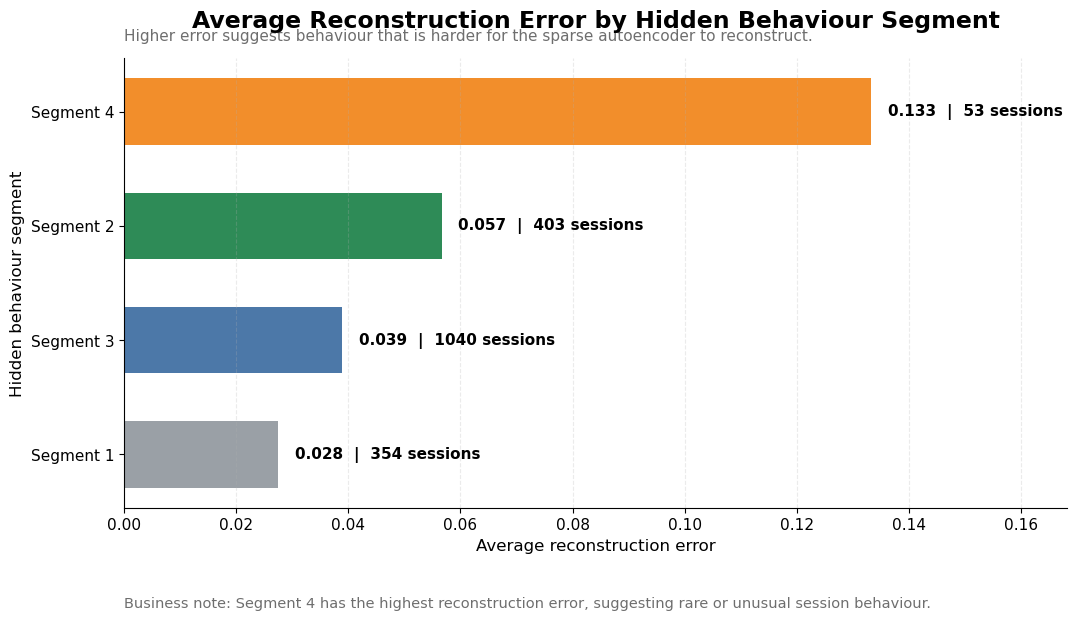

In [33]:
# ============================================================
# BI Chart: Reconstruction Error by Hidden Behaviour Segment
# ============================================================

error_segment_chart = segment_summary.sort_values(
    "Average_Reconstruction_Error",
    ascending=True
)

# Business-driven colors
error_color_map = {
    "Segment 1": "#9AA0A6",   # muted grey
    "Segment 2": "#2E8B57",   # green
    "Segment 3": "#4C78A8",   # blue
    "Segment 4": "#F28E2B"    # orange
}

fig, ax = plt.subplots(figsize=(11, 6.4))

bars = ax.barh(
    error_segment_chart["Segment Label"],
    error_segment_chart["Average_Reconstruction_Error"],
    color=[error_color_map[segment] for segment in error_segment_chart["Segment Label"]],
    height=0.58
)

for bar, error, sessions in zip(
    bars,
    error_segment_chart["Average_Reconstruction_Error"],
    error_segment_chart["Sessions"]
):
    ax.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{error:.3f}  |  {sessions} sessions",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

format_chart(
    ax=ax,
    title="Average Reconstruction Error by Hidden Behaviour Segment",
    subtitle="Higher error suggests behaviour that is harder for the sparse autoencoder to reconstruct.",
    xlabel="Average reconstruction error",
    ylabel="Hidden behaviour segment"
)

ax.text(
    0,
    -0.22,
    "Business note: Segment 4 has the highest reconstruction error, suggesting rare or unusual session behaviour.",
    transform=ax.transAxes,
    fontsize=10.5,
    color=COLOR_GREY
)

ax.set_xlim(0, error_segment_chart["Average_Reconstruction_Error"].max() + 0.035)

plt.tight_layout()
plt.show()

### Reconstruction Error by Segment — Conclusion

The reconstruction error chart shows how difficult each segment was for the sparse autoencoder to rebuild.

| Segment | Avg. Reconstruction Error | Business Meaning |
|---|---:|---|
| Segment 1 | 0.028 | Most typical / easiest to reconstruct |
| Segment 3 | 0.039 | Common behaviour with moderate error |
| Segment 2 | 0.057 | Higher-value behaviour with higher error |
| Segment 4 | 0.133 | Most unusual / hardest to reconstruct |

---

#### Main insight

**Segment 4** has the highest reconstruction error.

This means the sparse autoencoder found Segment 4 sessions harder to reconstruct.

This supports what we saw earlier:

- Segment 4 is very small.
- Segment 4 is visually separated in the PCA plot.
- Segment 4 has the highest purchase rate.
- Segment 4 also has the highest reconstruction error.

---

#### Business takeaway

Segment 4 may represent a rare but high-value behaviour pattern.

This segment should not be ignored just because it is small.

It may contain unusual sessions that are commercially interesting, such as visitors with strong purchase intent or uncommon shopping behaviour.

Segment 2 is also important because it has a high purchase rate and better volume than Segment 4.

Together, these charts show that sparse autoencoder features can support:

- segmentation,
- purchase behaviour analysis,
- and anomaly-style investigation.

Which segments are commercially attractive and which ones look unusual?

## 20. Segment Opportunity Matrix

Now we combine three business signals into one chart.

| Signal | Meaning |
|---|---|
| **Purchase Rate %** | How strongly the segment converts |
| **Average Reconstruction Error** | How unusual the segment behaviour is |
| **Session Share %** | How large the segment is |

This helps us identify which hidden behaviour segments are useful for business action.

A segment with high purchase rate and enough volume may be good for marketing campaigns.

A segment with high reconstruction error may show unusual behaviour that needs deeper investigation.

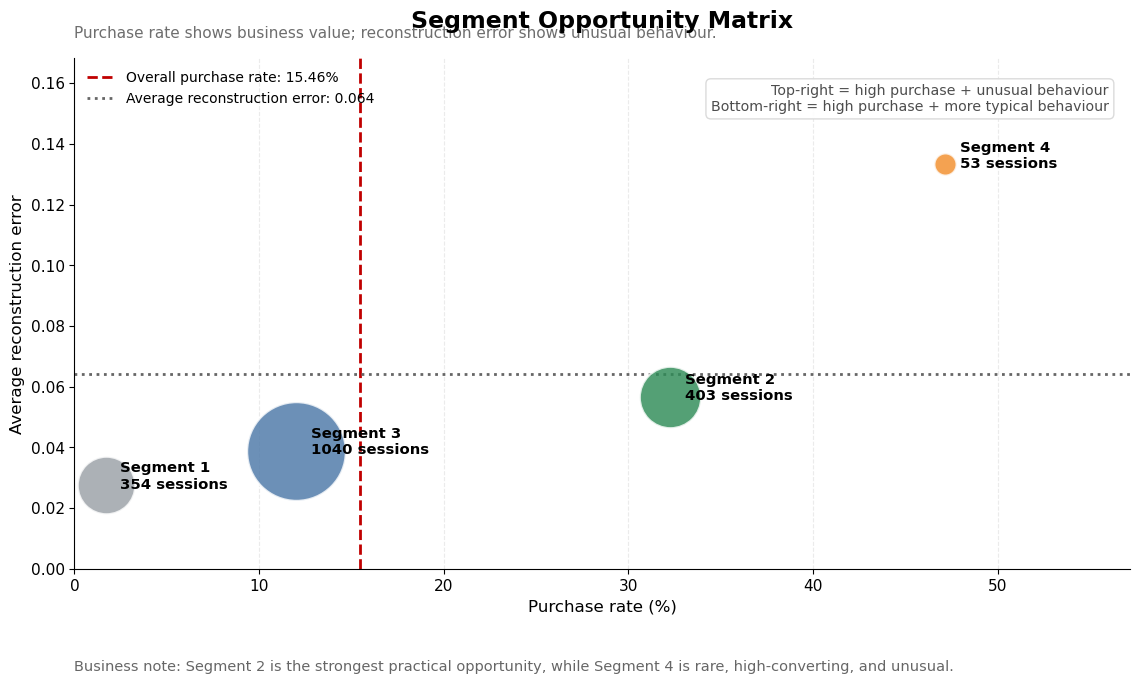

In [34]:
# ============================================================
# BI Chart: Segment Opportunity Matrix
# ============================================================

opportunity_chart = segment_summary.copy()

# Reference lines
overall_purchase_rate = test_revenue.mean() * 100
average_error = opportunity_chart["Average_Reconstruction_Error"].mean()

# Business-driven colours
segment_color_map = {
    "Segment 1": "#9AA0A6",   # low-value / weak purchase behaviour
    "Segment 2": "#2E8B57",   # strong practical opportunity
    "Segment 3": "#4C78A8",   # largest common behaviour group
    "Segment 4": "#F28E2B"    # rare high-value / unusual group
}

fig, ax = plt.subplots(figsize=(11.5, 7))

# Bubble size = segment size
for _, row in opportunity_chart.iterrows():
    ax.scatter(
        row["Purchase Rate %"],
        row["Average_Reconstruction_Error"],
        s=row["Session Share %"] * 90,
        color=segment_color_map[row["Segment Label"]],
        alpha=0.82,
        edgecolor="white",
        linewidth=1.6,
        zorder=3
    )

    ax.text(
        row["Purchase Rate %"] + 0.8,
        row["Average_Reconstruction_Error"] + 0.003,
        f'{row["Segment Label"]}\n{int(row["Sessions"])} sessions',
        fontsize=10.7,
        fontweight="bold",
        ha="left",
        va="center"
    )

# Reference lines
ax.axvline(
    overall_purchase_rate,
    color="#C00000",
    linestyle="--",
    linewidth=2,
    label=f"Overall purchase rate: {overall_purchase_rate:.2f}%"
)

ax.axhline(
    average_error,
    color="#666666",
    linestyle=":",
    linewidth=2,
    label=f"Average reconstruction error: {average_error:.3f}"
)

format_chart(
    ax=ax,
    title="Segment Opportunity Matrix",
    subtitle="Purchase rate shows business value; reconstruction error shows unusual behaviour.",
    xlabel="Purchase rate (%)",
    ylabel="Average reconstruction error"
)

# Business quadrant note
ax.text(
    0.98,
    0.95,
    "Top-right = high purchase + unusual behaviour\nBottom-right = high purchase + more typical behaviour",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10.2,
    color="#4d4d4d",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="#D9D9D9",
        alpha=0.95
    )
)

ax.legend(frameon=False, fontsize=10, loc="upper left")

ax.text(
    0,
    -0.20,
    "Business note: Segment 2 is the strongest practical opportunity, while Segment 4 is rare, high-converting, and unusual.",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#666666"
)

ax.set_xlim(0, opportunity_chart["Purchase Rate %"].max() + 10)
ax.set_ylim(0, opportunity_chart["Average_Reconstruction_Error"].max() + 0.035)

plt.tight_layout()
plt.show()

### Segment Opportunity Matrix — Conclusion

The opportunity matrix combines purchase rate, reconstruction error, and segment size.

| Segment | Interpretation |
|---|---|
| **Segment 1** | Low purchase rate and low reconstruction error. This looks like common low-intent behaviour. |
| **Segment 2** | High purchase rate with useful volume. This is the strongest practical marketing opportunity. |
| **Segment 3** | Largest segment, but purchase rate is below the overall average. This looks like common browsing behaviour. |
| **Segment 4** | Highest purchase rate and highest reconstruction error. This is rare, unusual, and commercially interesting. |

---

#### Main business takeaway

**Segment 2** is the most actionable segment because it combines strong purchase behaviour with meaningful session volume.

**Segment 4** is also important, but it is small and unusual.  
It should be investigated further, not treated as the main campaign segment immediately.

---

#### Why this matters

This chart shows how sparse autoencoder features can support business decisions.

The model did not only compress the data.  
It helped create behaviour groups that show different levels of purchase intent and unusual behaviour.

This supports the business use cases of:

- customer segmentation,
- purchase behaviour analysis,
- anomaly-style investigation,
- and future feature engineering.

## 21. Final Model Comparison Summary

We now summarise the main technical results from both autoencoders.

This table compares:

| Area | What it means |
|---|---|
| Validation loss | How well the model performed during training checks |
| Test reconstruction error | Final performance on unseen data |
| Average bottleneck activation | How strongly the bottleneck neurons were used |
| Near-zero activations | How much sparse behaviour was created |

This helps us clearly compare the normal autoencoder and sparse autoencoder.

In [35]:
# ============================================================
# Final Model Comparison Table
# ============================================================

final_model_summary = pd.DataFrame({
    "Metric": [
        "Validation Reconstruction Loss",
        "Average Test Reconstruction Error",
        "Average Bottleneck Activation",
        "Near-Zero Bottleneck Activations %"
    ],
    "Normal Autoencoder": [
        normal_loss["val_loss"].iloc[-1],
        test_error_summary.loc[
            test_error_summary["Model"] == "Normal Autoencoder",
            "Average Test Reconstruction Error"
        ].iloc[0],
        bottleneck_summary.loc[
            bottleneck_summary["Model"] == "Normal Autoencoder",
            "Average Bottleneck Activation"
        ].iloc[0],
        bottleneck_summary.loc[
            bottleneck_summary["Model"] == "Normal Autoencoder",
            "Near-Zero Activations %"
        ].iloc[0]
    ],
    "Sparse Autoencoder": [
        sparse_loss["val_loss"].iloc[-1],
        test_error_summary.loc[
            test_error_summary["Model"] == "Sparse Autoencoder",
            "Average Test Reconstruction Error"
        ].iloc[0],
        bottleneck_summary.loc[
            bottleneck_summary["Model"] == "Sparse Autoencoder",
            "Average Bottleneck Activation"
        ].iloc[0],
        bottleneck_summary.loc[
            bottleneck_summary["Model"] == "Sparse Autoencoder",
            "Near-Zero Activations %"
        ].iloc[0]
    ]
})

final_model_summary.round(6)

,Metric,Normal Autoencoder,Sparse Autoencoder
0,Validation Reconstruction Loss,0.036117,0.045389
1,Average Test Reconstruction Error,0.034884,0.043283
2,Average Bottleneck Activation,2.487932,1.762660
3,Near-Zero Bottleneck Activations %,0.198305,0.585902


### Final Model Comparison — Conclusion

The final comparison shows the main trade-off between the normal autoencoder and the sparse autoencoder.

| Metric | Normal Autoencoder | Sparse Autoencoder | Interpretation |
|---|---:|---:|---|
| Validation Reconstruction Loss | 0.036117 | 0.045389 | Normal autoencoder reconstructed validation data better |
| Average Test Reconstruction Error | 0.034884 | 0.043283 | Normal autoencoder also performed better on unseen test data |
| Average Bottleneck Activation | 2.487932 | 1.762660 | Sparse autoencoder used lower hidden activity |
| Near-Zero Bottleneck Activations | 0.198305% | 0.585902% | Sparse autoencoder pushed more hidden values closer to zero |

---

#### Main interpretation

The **normal autoencoder** had better reconstruction performance.

This means it rebuilt the original website-session features more accurately.

The **sparse autoencoder** had slightly weaker reconstruction performance, but it created a more compact hidden representation.

This means it used the bottleneck less strongly and pushed more bottleneck values closer to zero.

---

#### Business meaning

The sparse autoencoder was useful because its hidden bottleneck features helped create behaviour segments.

Those segments showed different business patterns:

| Segment | Business Meaning |
|---|---|
| Segment 1 | Low purchase behaviour |
| Segment 2 | Strong practical marketing opportunity |
| Segment 3 | Common browsing behaviour |
| Segment 4 | Rare, unusual, high-converting behaviour |

---

#### Final takeaway

The sparse autoencoder did not win on reconstruction accuracy.

But it was valuable because it created hidden behaviour features that supported business interpretation.

This is the key learning:

> Sparse autoencoders may sacrifice some reconstruction accuracy, but they can create simpler hidden features that are useful for customer behaviour analysis.